#### Demonstrate the output of the following functions using a paragraph in the corpus:

In [1]:
import os
from tqdm import tqdm
import time
import glob
import pandas as pd
import numpy as np
import sys
sys.path.append('..')

from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "last_expr"  # Show only the last expression

import matplotlib.pyplot as plt
import seaborn as sns

from pipeline import Pipeline
from modules.retrieval.reranker import Reranker
from modules.generator.question_answering import QA_Generator
from modules.metrics import Metrics_Automated

os.environ["MISTRAL_API_KEY"] = "TGwZGwfx2CCPujKn7FEq6uNLh3nQZxLh"

pipeline = Pipeline()
corpus_dir = '../storage/corpus_sample'

chuncks1 = pipeline.preprocess_corpus(corpus_dir, chunking_strategy='sentence', overlap_size=2)
pipeline.display_chunks()

[nltk_data] Downloading package punkt_tab to
[nltk_data]     /Users/sichaoliu/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
/Users/sichaoliu/anaconda3/envs/AiSys/lib/python3.12/site-packages/sentence_transformers/cross_encoder/CrossEncoder.py:13: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from tqdm.autonotebook import tqdm, trange
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /Users/sichaoliu/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package punkt to /Users/sichaoliu/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     /Users/sichaoliu/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     /Users/sichaoliu/nltk_data

Number of chunks: 502

Chunks:

Chunk 1:
Theodore Roosevelt Theodore Roosevelt, Jr. ( ; October 27 1858 January 6 1919), also known as T.R., and to the public (but never to friends and intimates) as Teddy, was the twenty-sixth President of the United States, and a leader of the Republican Party and of the Progressive Movement. He became the youngest President in United States history at the age of 42.

Chunk 2:
He served in many roles including Governor of New York, historian, naturalist, explorer, author, and soldier. Roosevelt is most famous for his personality: his energy, his vast range of interests and achievements, his model of masculinity, and his "cowboy" persona.

Chunk 3:
His last name, often mispronounced, is, per Roosevelt, "pronounced as if it were spelled 'Rosavelt', in three syllables, the first syllable as if it was 'Rose.'" As Assistant Secretary of the U.S. Navy, he prepared for and advocated war with Spain in 1898.

Chunk 4:
He organized and helped command the 1st U.

In [2]:
chuncks2 = pipeline.preprocess_corpus(corpus_dir, chunking_strategy='sentence', overlap_size=4)
pipeline.display_chunks()

Number of chunks: 251

Chunks:

Chunk 1:
Theodore Roosevelt Theodore Roosevelt, Jr. ( ; October 27 1858 January 6 1919), also known as T.R., and to the public (but never to friends and intimates) as Teddy, was the twenty-sixth President of the United States, and a leader of the Republican Party and of the Progressive Movement. He became the youngest President in United States history at the age of 42. He served in many roles including Governor of New York, historian, naturalist, explorer, author, and soldier. Roosevelt is most famous for his personality: his energy, his vast range of interests and achievements, his model of masculinity, and his "cowboy" persona.

Chunk 2:
His last name, often mispronounced, is, per Roosevelt, "pronounced as if it were spelled 'Rosavelt', in three syllables, the first syllable as if it was 'Rose.'" As Assistant Secretary of the U.S. Navy, he prepared for and advocated war with Spain in 1898. He organized and helped command the 1st U.S. Volunteer Cavalry

In [3]:
chuncks3 = pipeline.preprocess_corpus(corpus_dir, chunking_strategy='fixed-length', fixed_length=50, overlap_size=3)
pipeline.display_chunks()

Number of chunks: 455

Chunks:

Chunk 1:
Theodore Roosevelt Theodore Roosevelt, Jr. ( ; October 27 1858 January 6 1919), also known as T.R., and to the public (but never to friends and intimates) as Teddy, was the twenty-sixth President of the United States, and a leader of the Republican Party and of the Progressive Movement. He

Chunk 2:
Progressive Movement. He became the youngest President in United States history at the age of 42. He served in many roles including Governor of New York, historian, naturalist, explorer, author, and soldier. Roosevelt is most famous for his personality: his energy, his vast range of interests and achievements, his model

Chunk 3:
achievements, his model of masculinity, and his "cowboy" persona. His last name, often mispronounced, is, per Roosevelt, "pronounced as if it were spelled 'Rosavelt', in three syllables, the first syllable as if it was 'Rose.'" As Assistant Secretary of the U.S. Navy, he prepared for and advocated war with Spain

Chunk 4:
wa

In [4]:
chuncks4 = pipeline.preprocess_corpus(corpus_dir, chunking_strategy='fixed-length', fixed_length=100, overlap_size=2)
pipeline.display_chunks()

Number of chunks: 218

Chunks:

Chunk 1:
Theodore Roosevelt Theodore Roosevelt, Jr. ( ; October 27 1858 January 6 1919), also known as T.R., and to the public (but never to friends and intimates) as Teddy, was the twenty-sixth President of the United States, and a leader of the Republican Party and of the Progressive Movement. He became the youngest President in United States history at the age of 42. He served in many roles including Governor of New York, historian, naturalist, explorer, author, and soldier. Roosevelt is most famous for his personality: his energy, his vast range of interests and achievements, his model of masculinity, and

Chunk 2:
masculinity, and his "cowboy" persona. His last name, often mispronounced, is, per Roosevelt, "pronounced as if it were spelled 'Rosavelt', in three syllables, the first syllable as if it was 'Rose.'" As Assistant Secretary of the U.S. Navy, he prepared for and advocated war with Spain in 1898. He organized and helped command the 1st U.S. 

In [5]:
chuncks5 = pipeline.preprocess_corpus(corpus_dir, chunking_strategy='fixed-length', fixed_length=150, overlap_size=1)
pipeline.display_chunks()

Number of chunks: 144

Chunks:

Chunk 1:
Theodore Roosevelt Theodore Roosevelt, Jr. ( ; October 27 1858 January 6 1919), also known as T.R., and to the public (but never to friends and intimates) as Teddy, was the twenty-sixth President of the United States, and a leader of the Republican Party and of the Progressive Movement. He became the youngest President in United States history at the age of 42. He served in many roles including Governor of New York, historian, naturalist, explorer, author, and soldier. Roosevelt is most famous for his personality: his energy, his vast range of interests and achievements, his model of masculinity, and his "cowboy" persona. His last name, often mispronounced, is, per Roosevelt, "pronounced as if it were spelled 'Rosavelt', in three syllables, the first syllable as if it was 'Rose.'" As Assistant Secretary of the U.S. Navy, he prepared for and advocated war with Spain in 1898. He organized and helped

Chunk 2:
helped command the 1st U.S. Volunteer 

#### In a notebook called notebooks/reranker_analysis.ipynb, visually analyze four re-ranking strategies and assess how your findings will impact your system design:

In [2]:
questions_path = '../qa_resources/questions.csv'
corpus_directory = '../storage/corpus/*.txt.clean'  

questions = pd.read_csv(questions_path, sep='\t')

# context = []
# for filepath in glob.glob(corpus_directory):
#     with open(filepath, 'r') as file:
#         # context.append(file.read())
#         for line in file.readlines():
#             context.append(line.strip())
context = chuncks1['chunks']

generator_model = "mistral-large-latest"
generator = QA_Generator(api_key = os.environ["MISTRAL_API_KEY"], temperature=0.2, generator_model=generator_model)

metrics = Metrics_Automated()

def plot_results(scores, title):
    plt.figure(figsize=(10, 5))
    
    plt.plot(scores, marker='o', linestyle='-', color='b', markersize=6)
    plt.title(title)
    plt.xlabel("Ranked Index")
    plt.ylabel("Score")
    plt.tight_layout()
    plt.show()

Using device: cpu


##### Analyze the model's performance using the re-rankers and modules.generator.question_answering.QA_generator class. For each result, discuss how your findings will impact your system design. You may use questions from questions.csv and a subset of the document in the corpus (avoiding the need to handle vector embeddings), or you may implement the entire pipeline, including the search and indexing modules.

##### Cross-encoder-only strategy 

`The cross-encoder is excellent for top results, capturing subtle connections between the query and document, which makes it highly accurate for complex queries. However, this level of precision is costly in terms of computation, making the cross-encoder too resource-intensive for large datasets or real-time applications. In system design, it is most effective when used for re-ranking a small subset of top candidates generated by an initial, faster retrieval method, balancing accuracy and efficiency.`

[ChatCompletionChoice(index=0, message=AssistantMessage(content='No context.', tool_calls=None, prefix=False, role='assistant'), finish_reason='stop')]


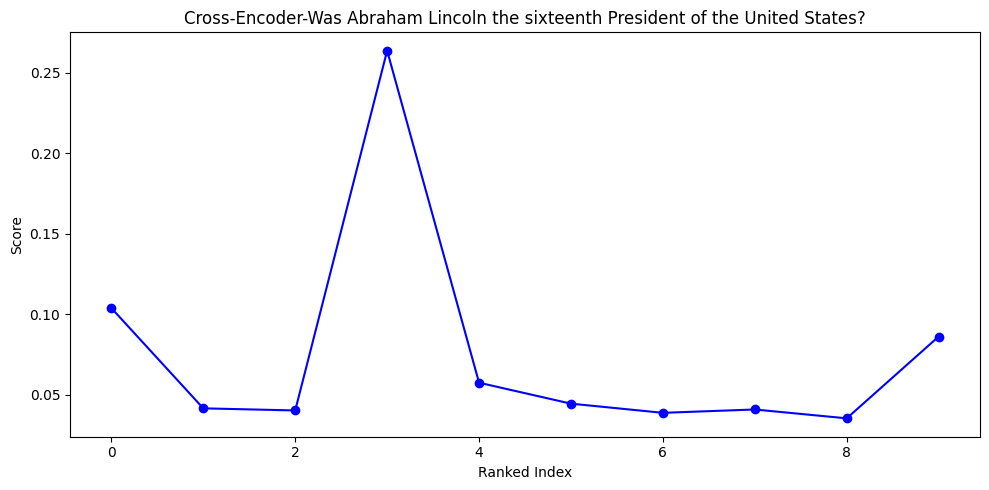

[ChatCompletionChoice(index=0, message=AssistantMessage(content='No context.', tool_calls=None, prefix=False, role='assistant'), finish_reason='stop')]


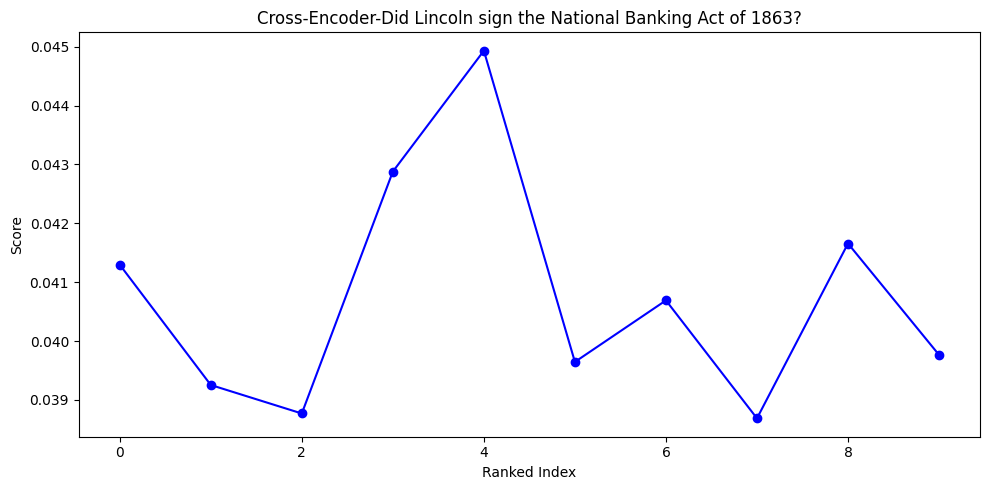

[ChatCompletionChoice(index=0, message=AssistantMessage(content='No context.', tool_calls=None, prefix=False, role='assistant'), finish_reason='stop')]


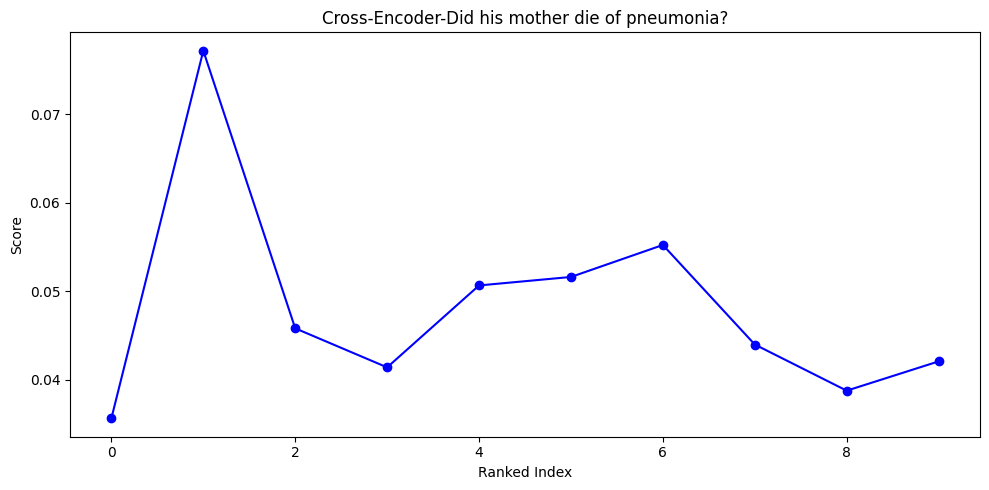

[ChatCompletionChoice(index=0, message=AssistantMessage(content='No context.', tool_calls=None, prefix=False, role='assistant'), finish_reason='stop')]


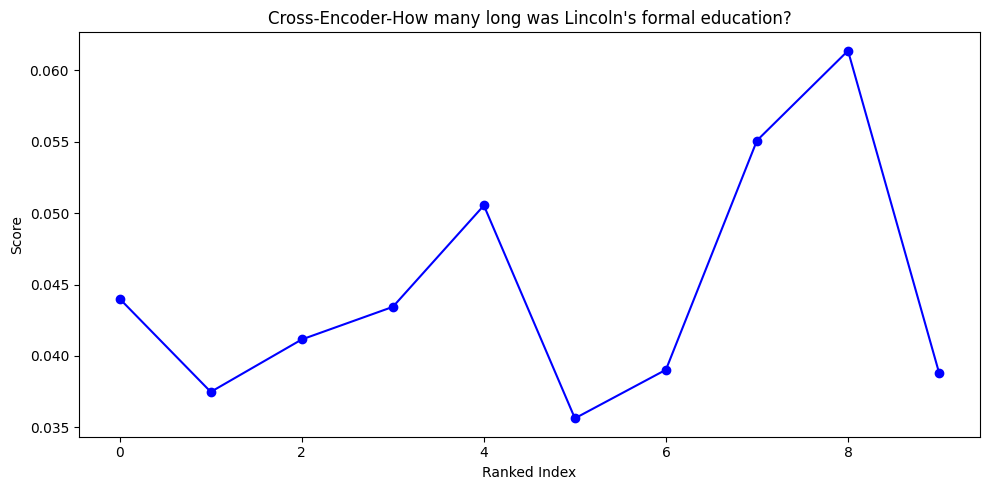

[ChatCompletionChoice(index=0, message=AssistantMessage(content='No context.', tool_calls=None, prefix=False, role='assistant'), finish_reason='stop')]


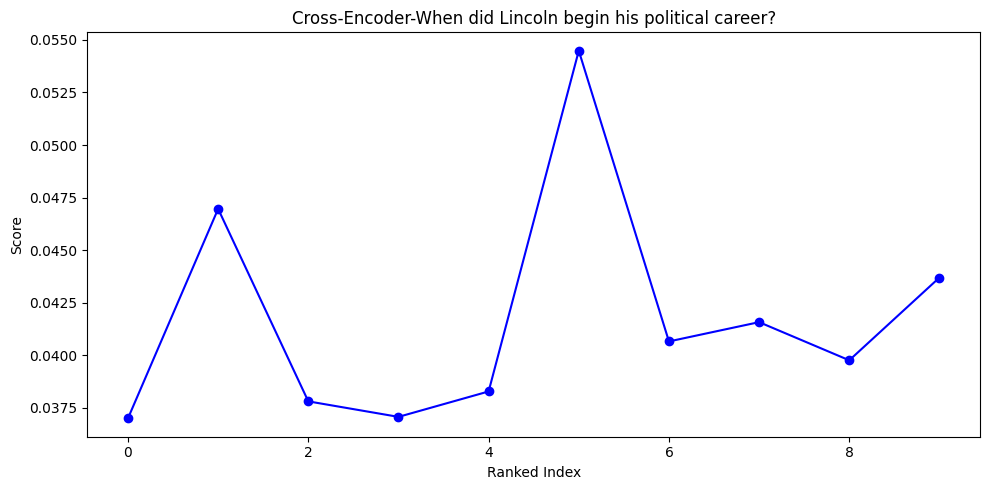

[ChatCompletionChoice(index=0, message=AssistantMessage(content='No context.', tool_calls=None, prefix=False, role='assistant'), finish_reason='stop')]


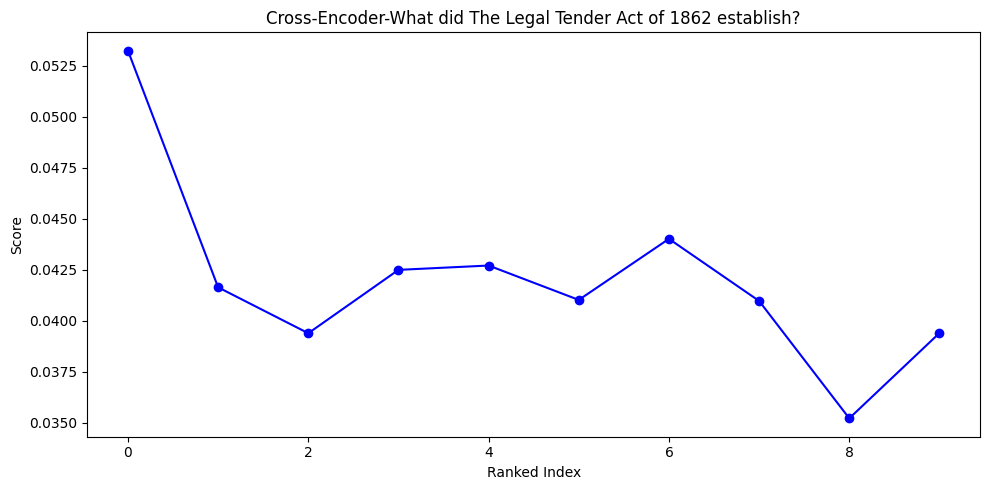

[ChatCompletionChoice(index=0, message=AssistantMessage(content='No context.', tool_calls=None, prefix=False, role='assistant'), finish_reason='stop')]


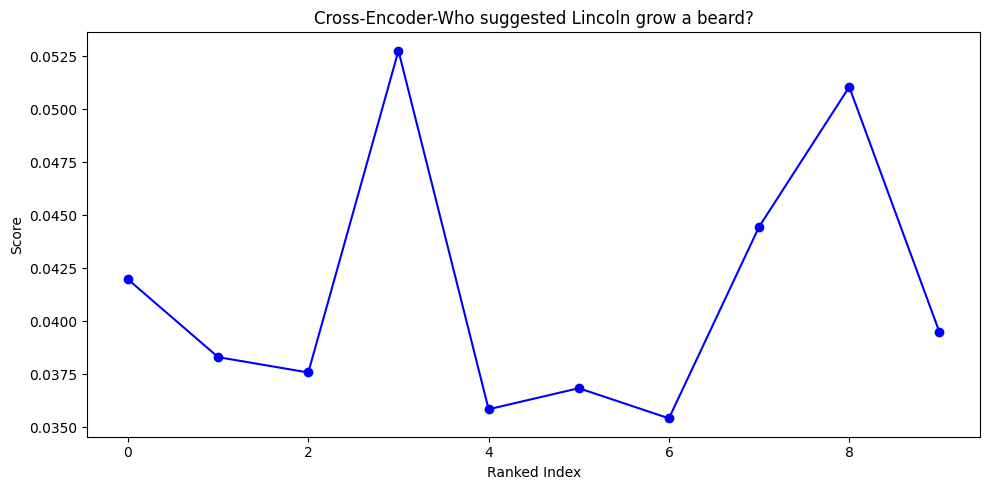

[ChatCompletionChoice(index=0, message=AssistantMessage(content='No context.', tool_calls=None, prefix=False, role='assistant'), finish_reason='stop')]


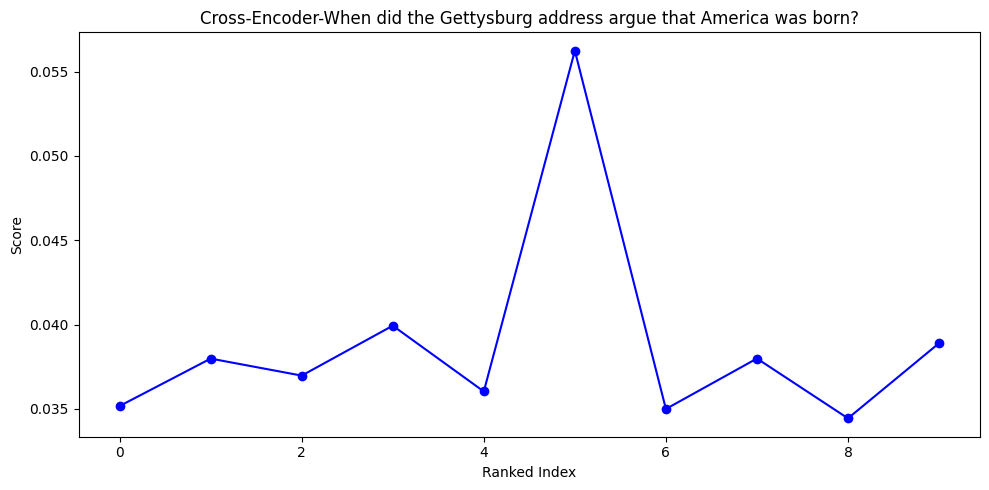

[ChatCompletionChoice(index=0, message=AssistantMessage(content='No context.', tool_calls=None, prefix=False, role='assistant'), finish_reason='stop')]


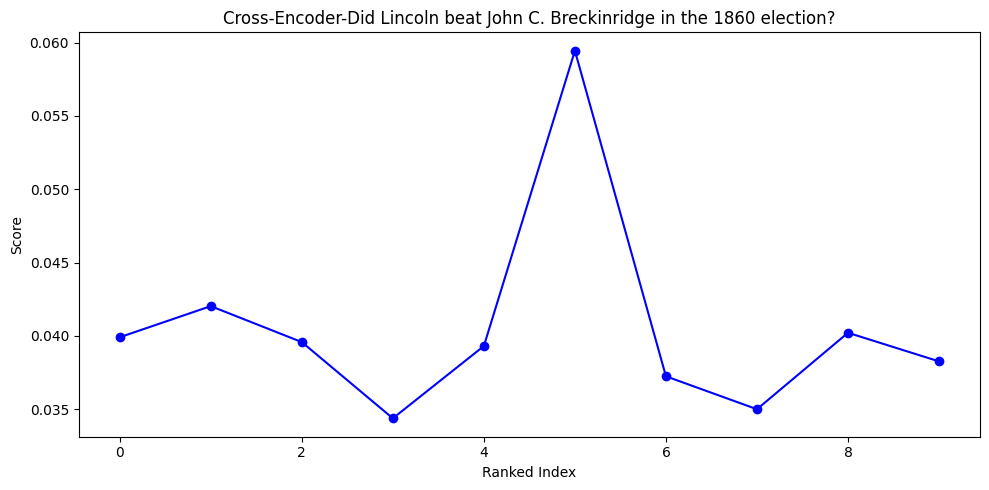

[ChatCompletionChoice(index=0, message=AssistantMessage(content='No context.', tool_calls=None, prefix=False, role='assistant'), finish_reason='stop')]


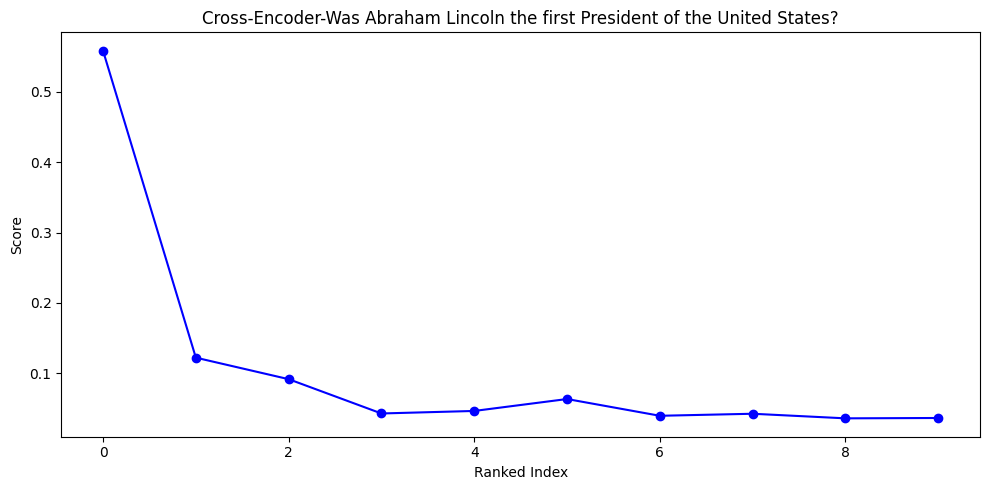

In [3]:
reranker1 = Reranker(type="cross_encoder")
for question in questions['Question'][1:20:2]:
    documents, indices, _ = reranker1.rerank(question, context)
    answer = generator.generate_answer(question, context)
    scores = []
    for generated_answer in documents:
        score, _ = metrics.transformer_match(generated_answer, answer, question)
        scores.append(score[answer][generated_answer])
    plot_results(scores[:10], f"Cross-Encoder-{question}")


##### TF-IDF-only strategy, encode only the context provided (See modules.retrieval.Reranker.tfidf_rerank() method) 

`By focusing solely on term frequency-inverse document frequency within the retrieved context, this approach offers extremely fast O(m*k) performance and minimal resource usage, but sacrifices semantic understanding. It's particularly effective for keyword-heavy queries and when document collections contain straightforward, literal matches, though it struggles with paraphrasing and contextual meaning. The lightweight nature of this strategy enables a simpler system architecture focused on high throughput. The design should emphasize fast memory access patterns, potentially using memory-mapped files for the TF-IDF matrices. A multithreaded architecture can easily handle concurrent requests without heavy resource contention.`

[ChatCompletionChoice(index=0, message=AssistantMessage(content='No context.', tool_calls=None, prefix=False, role='assistant'), finish_reason='stop')]


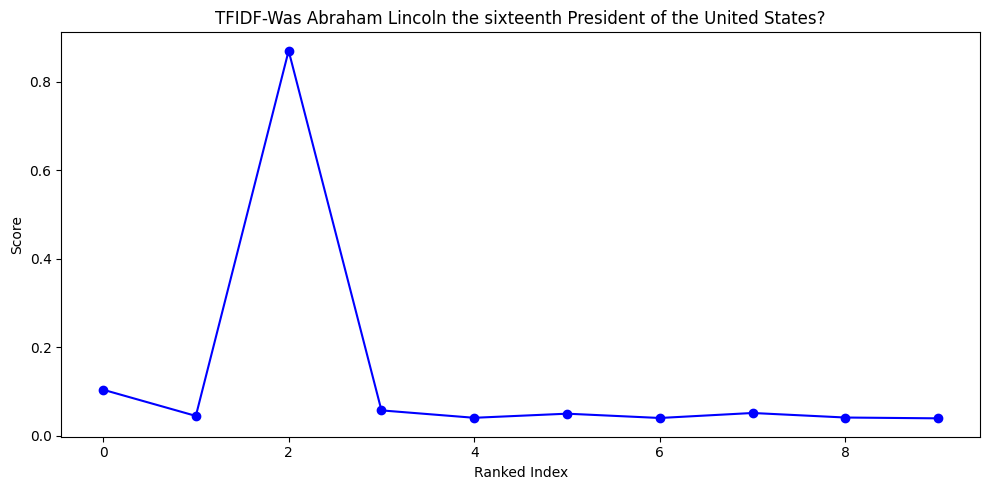

[ChatCompletionChoice(index=0, message=AssistantMessage(content='No context.', tool_calls=None, prefix=False, role='assistant'), finish_reason='stop')]


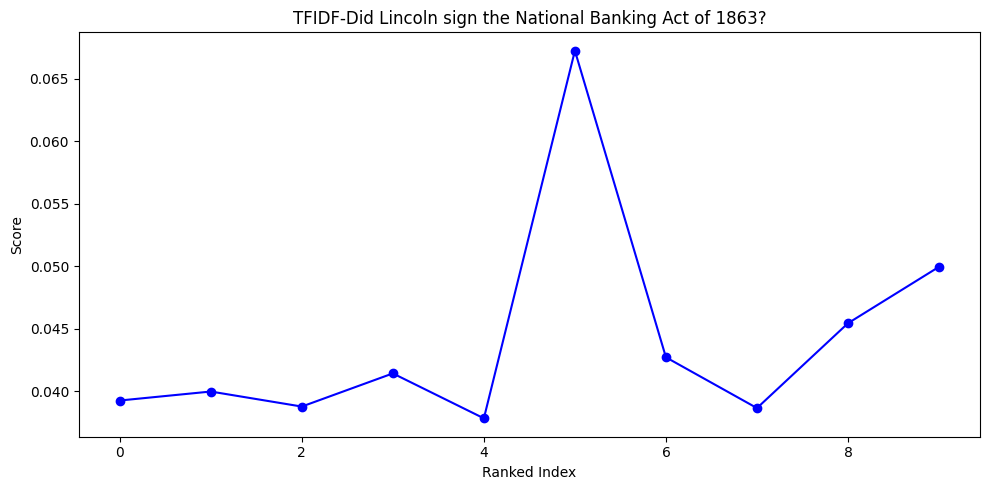

[ChatCompletionChoice(index=0, message=AssistantMessage(content='No context.', tool_calls=None, prefix=False, role='assistant'), finish_reason='stop')]


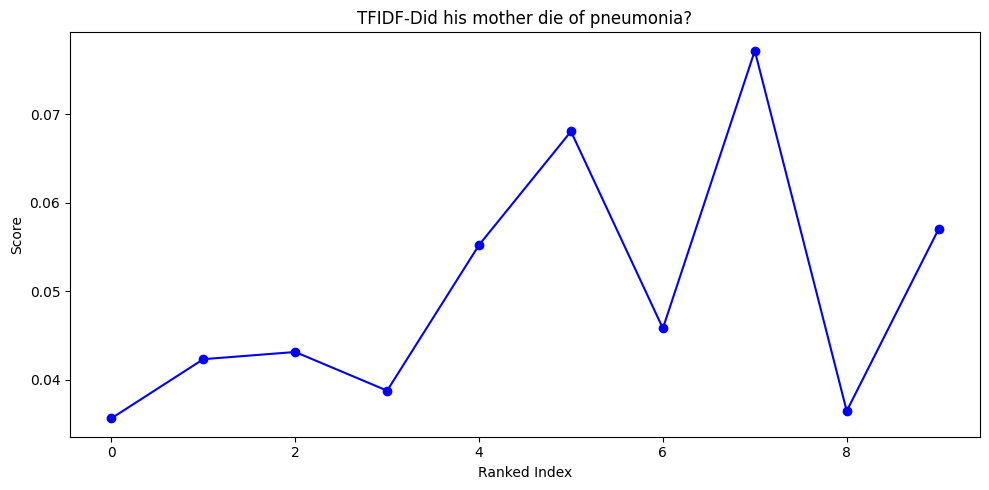

[ChatCompletionChoice(index=0, message=AssistantMessage(content='No context.', tool_calls=None, prefix=False, role='assistant'), finish_reason='stop')]


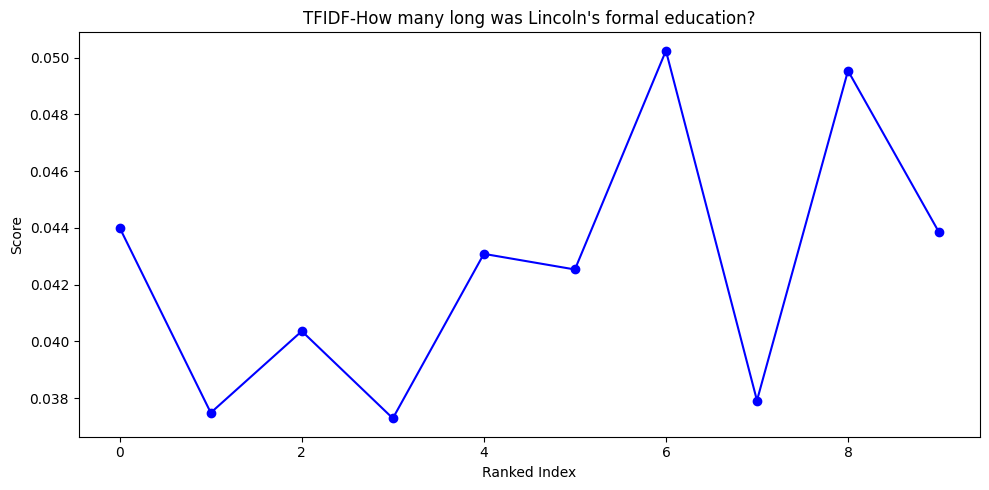

[ChatCompletionChoice(index=0, message=AssistantMessage(content='No context.', tool_calls=None, prefix=False, role='assistant'), finish_reason='stop')]


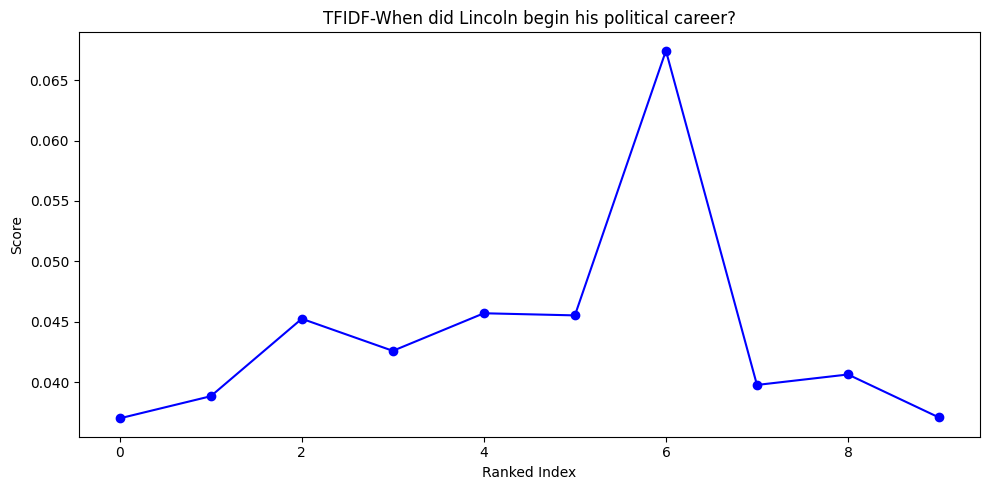

[ChatCompletionChoice(index=0, message=AssistantMessage(content='No context.', tool_calls=None, prefix=False, role='assistant'), finish_reason='stop')]


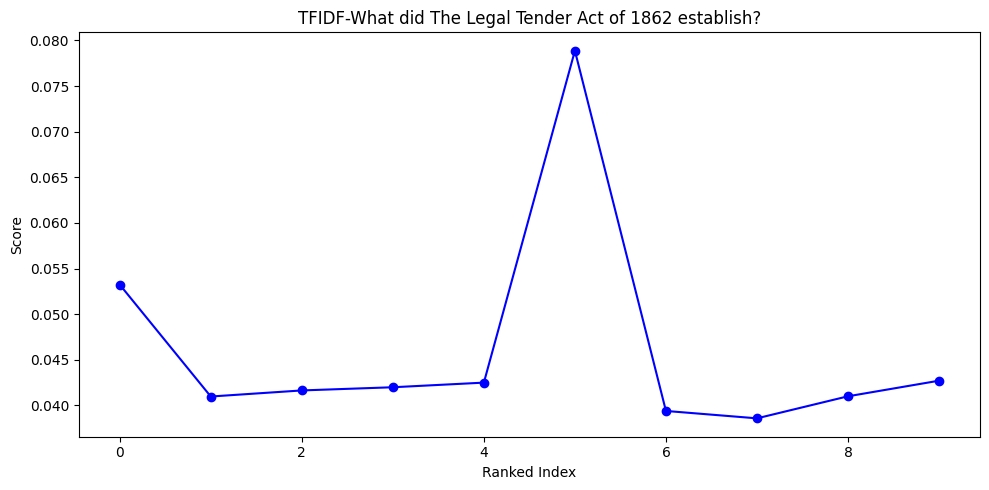

[ChatCompletionChoice(index=0, message=AssistantMessage(content='No context.', tool_calls=None, prefix=False, role='assistant'), finish_reason='stop')]


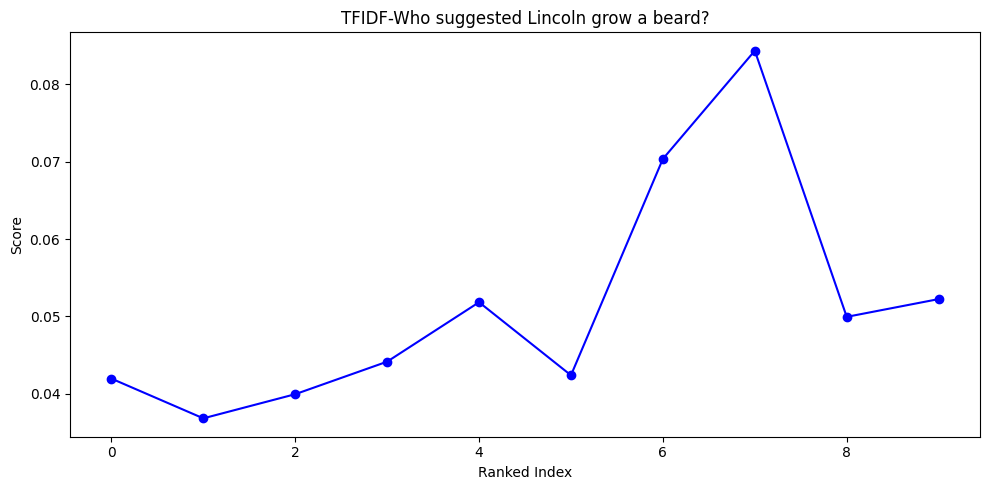

[ChatCompletionChoice(index=0, message=AssistantMessage(content='No context.', tool_calls=None, prefix=False, role='assistant'), finish_reason='stop')]


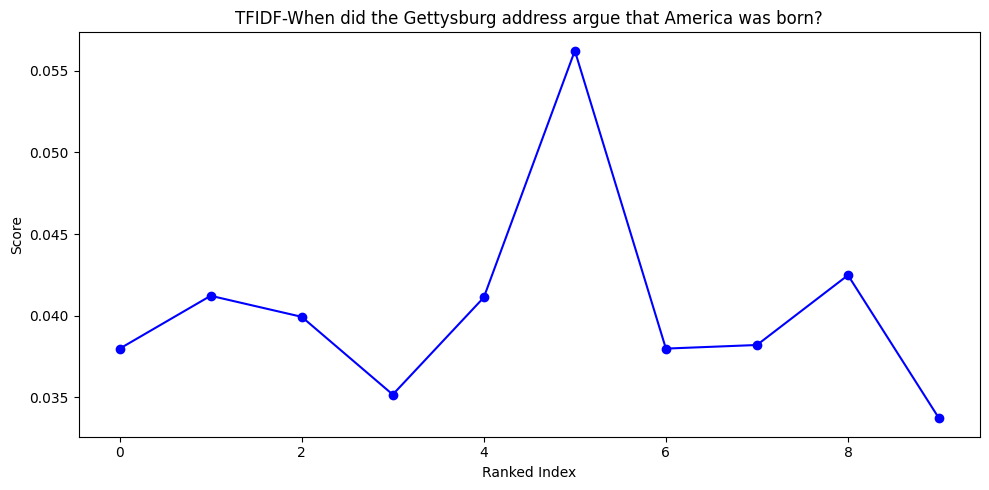

[ChatCompletionChoice(index=0, message=AssistantMessage(content='No context.', tool_calls=None, prefix=False, role='assistant'), finish_reason='stop')]


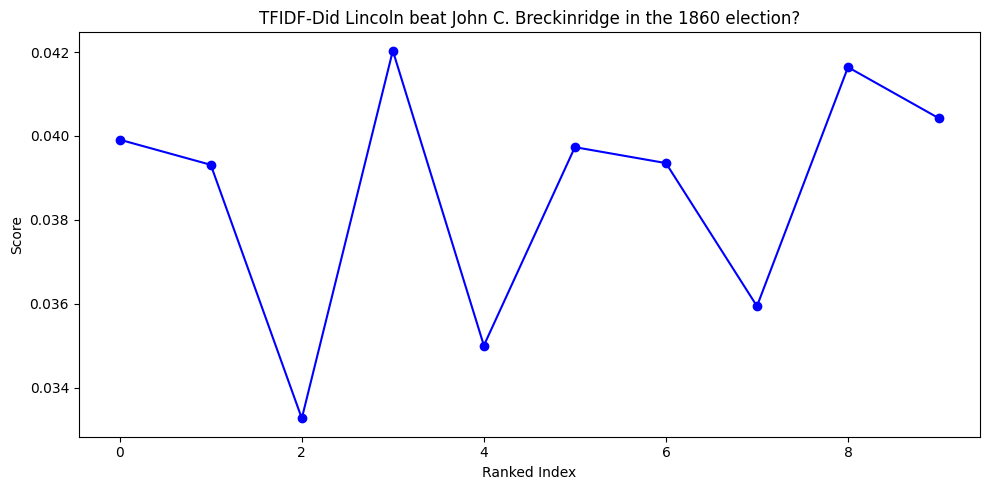

[ChatCompletionChoice(index=0, message=AssistantMessage(content='No context.', tool_calls=None, prefix=False, role='assistant'), finish_reason='stop')]


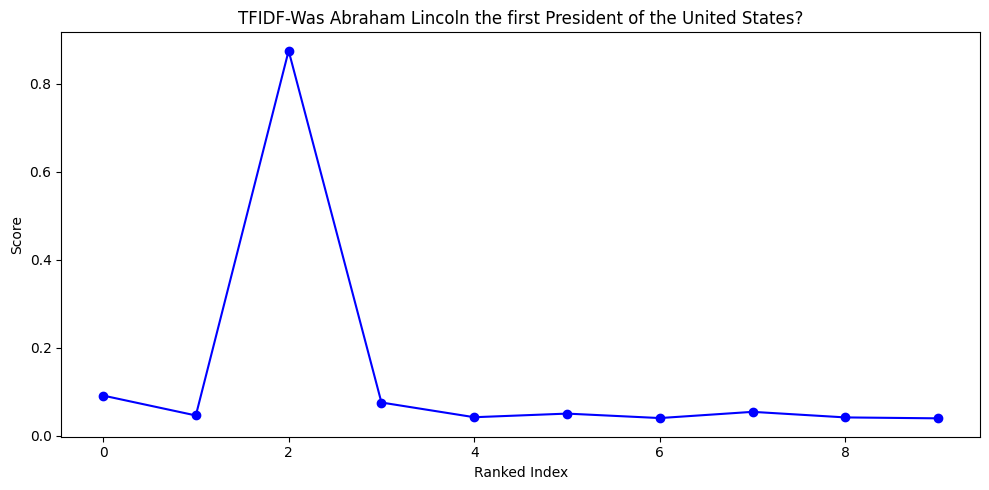

In [8]:
reranker2 = Reranker(type="tfidf")
for question in questions['Question'][1:20:2]:
    documents, indices, _ = reranker2.rerank(question, context)
    answer = generator.generate_answer(question, context)
    scores = []
    for generated_answer in documents:
        score, _ = metrics.transformer_match(generated_answer, answer, question)
        scores.append(score[answer][generated_answer])
    plot_results(scores[:10], f"TFIDF-{question}")


##### Cross-encoder and TF-IDF hybrid strategy (See modules.retrieval.Reranker.hybrid_rerank() method)

`This balanced strategy integrates the semantic strengths of cross-encoders with the efficiency of TF-IDF, allowing for adjustable weighted scoring tailored to specific use cases. While it demands more setup and has a moderate complexity of O(n + m * k), it offers a strong solution capable of effectively managing both literal and semantic matching. This approach is particularly well-suited when ranking accuracy and processing speed are both essential.The design should include a parameter tuning infrastructure to optimize weights between the two approaches, monitoring systems to track performance metrics, and potentially an A/B testing framework.`

[ChatCompletionChoice(index=0, message=AssistantMessage(content='No context.', tool_calls=None, prefix=False, role='assistant'), finish_reason='stop')]


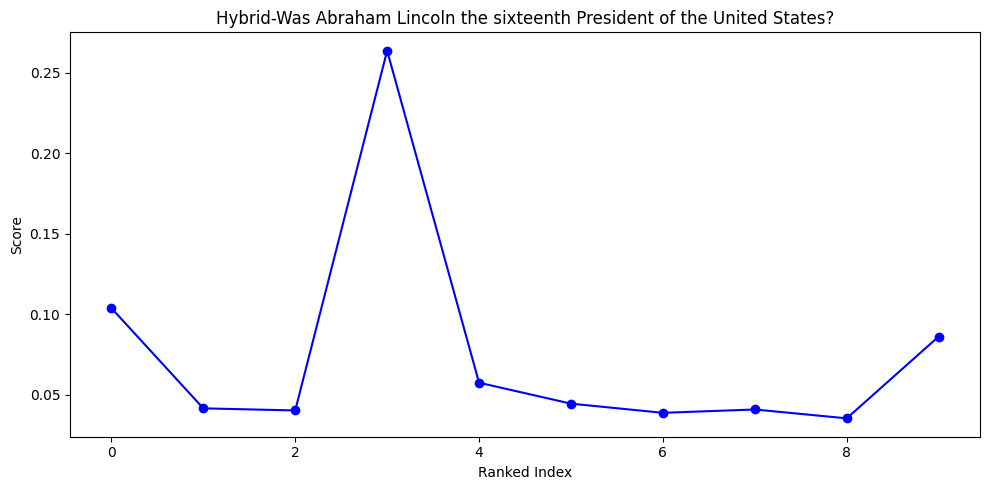

[ChatCompletionChoice(index=0, message=AssistantMessage(content='No context.', tool_calls=None, prefix=False, role='assistant'), finish_reason='stop')]


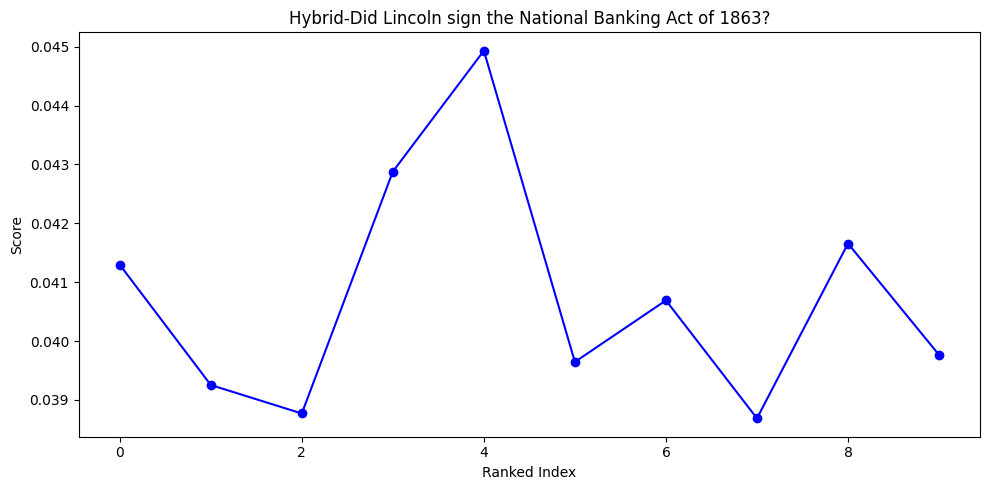

[ChatCompletionChoice(index=0, message=AssistantMessage(content='No context.', tool_calls=None, prefix=False, role='assistant'), finish_reason='stop')]


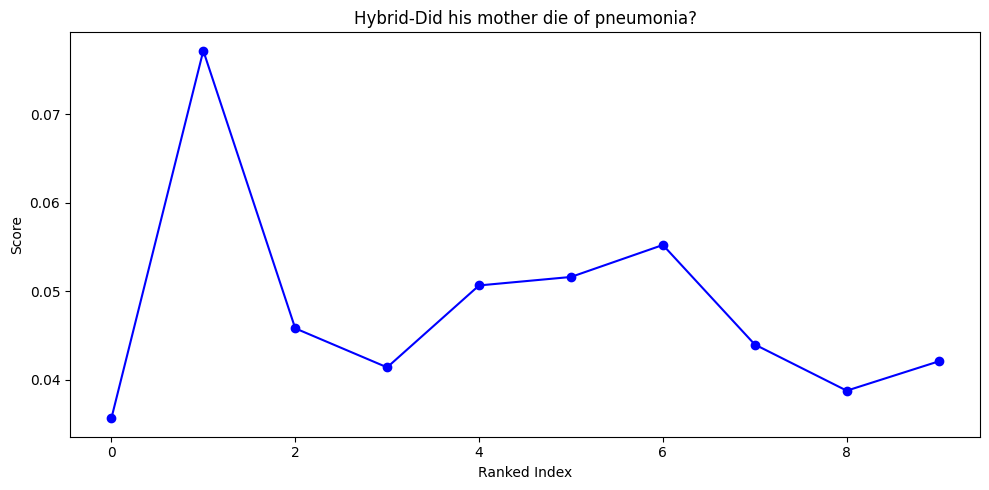

[ChatCompletionChoice(index=0, message=AssistantMessage(content='No context.', tool_calls=None, prefix=False, role='assistant'), finish_reason='stop')]


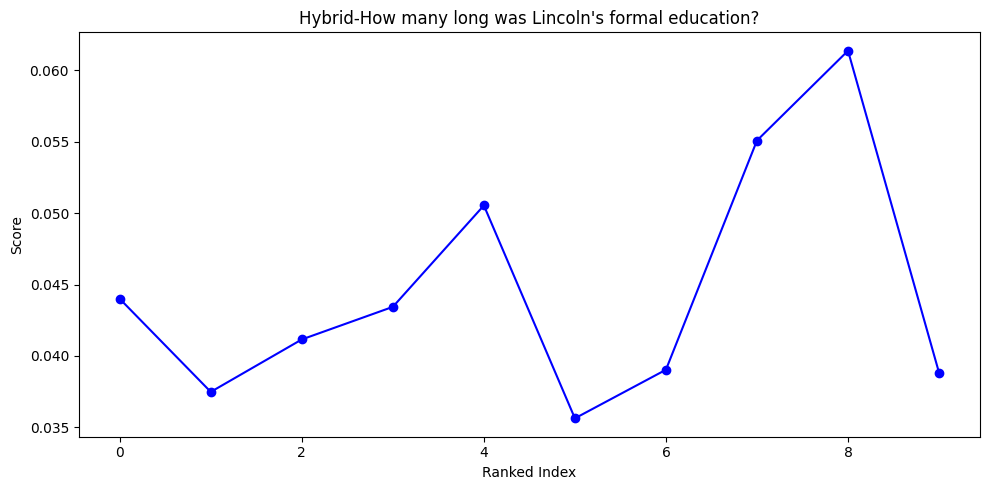

[ChatCompletionChoice(index=0, message=AssistantMessage(content='No context.', tool_calls=None, prefix=False, role='assistant'), finish_reason='stop')]


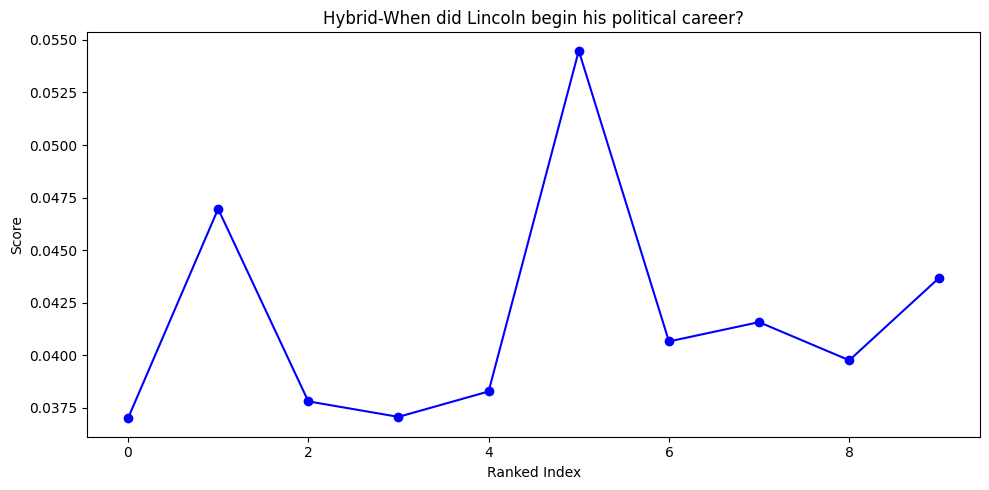

[ChatCompletionChoice(index=0, message=AssistantMessage(content='No context.', tool_calls=None, prefix=False, role='assistant'), finish_reason='stop')]


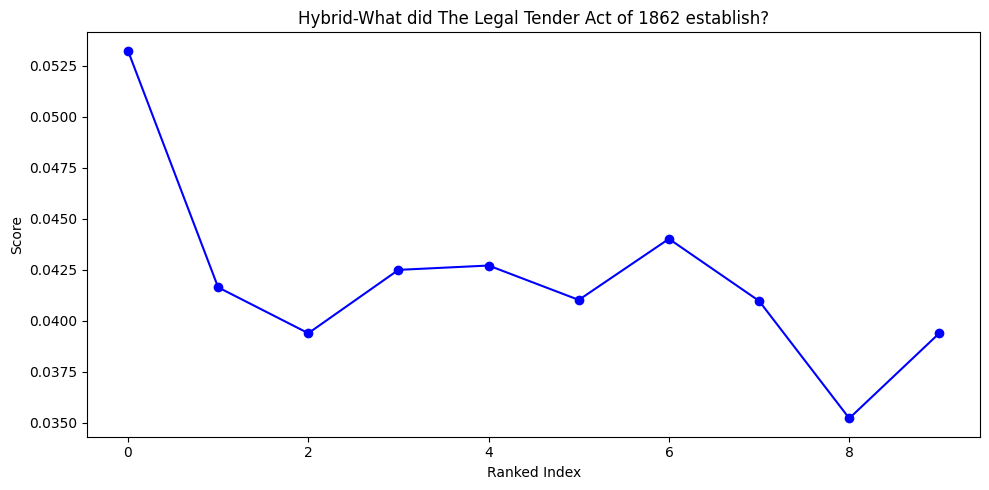

[ChatCompletionChoice(index=0, message=AssistantMessage(content='No context.', tool_calls=None, prefix=False, role='assistant'), finish_reason='stop')]


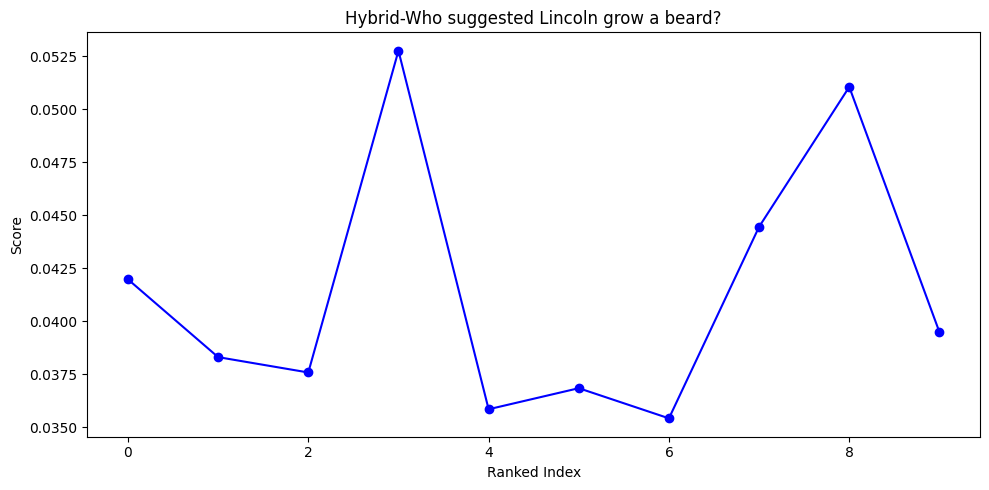

[ChatCompletionChoice(index=0, message=AssistantMessage(content='No context.', tool_calls=None, prefix=False, role='assistant'), finish_reason='stop')]


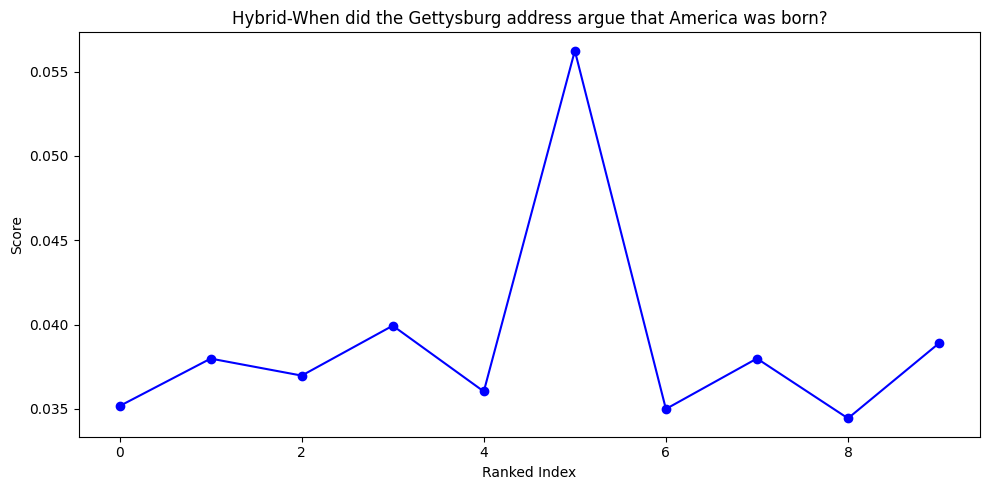

[ChatCompletionChoice(index=0, message=AssistantMessage(content='No context.', tool_calls=None, prefix=False, role='assistant'), finish_reason='stop')]


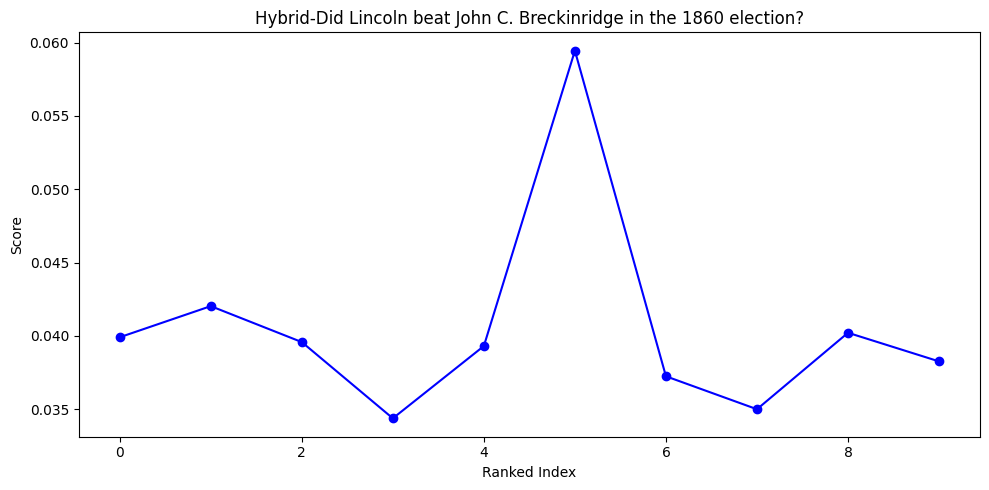

[ChatCompletionChoice(index=0, message=AssistantMessage(content='No context.', tool_calls=None, prefix=False, role='assistant'), finish_reason='stop')]


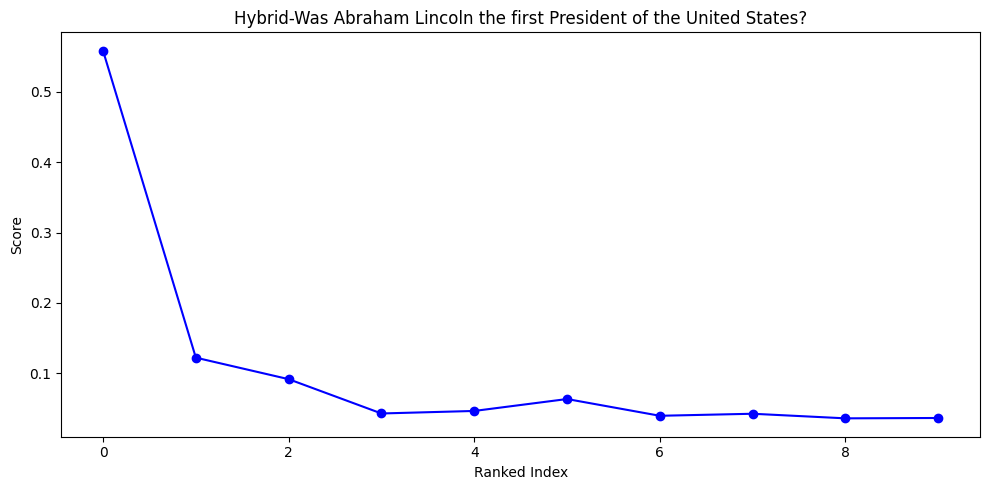

In [9]:
reranker3 = Reranker(type="hybrid")
for question in questions['Question'][1:20:2]:
    documents, indices, _ = reranker3.rerank(question, context)
    answer = generator.generate_answer(question, context)
    scores = []
    for generated_answer in documents:
        score, _ = metrics.transformer_match(generated_answer, answer, question)
        scores.append(score[answer][generated_answer])
    plot_results(scores[:10], f"Hybrid-{question}")


##### TF-IDF, then cross-encoder strategy. You will need to implement a function called modules.retrieval.Reranker.sequential_rerank().

`This approach uses TF-IDF as a fast initial filter to reduce the candidate pool before applying more expensive cross-encoder scoring, creating an efficient pipeline that balances speed and accuracy. The two-stage process significantly reduces the computational overhead compared to pure cross-encoder approaches while maintaining relatively high accuracy by letting TF-IDF do the heavy lifting of initial filtering. The design should incorporate configurable thresholds for the number of candidates passed to the cross-encoder stage, with monitoring systems to optimize these thresholds based on performance metrics.`

[ChatCompletionChoice(index=0, message=AssistantMessage(content='No context.', tool_calls=None, prefix=False, role='assistant'), finish_reason='stop')]


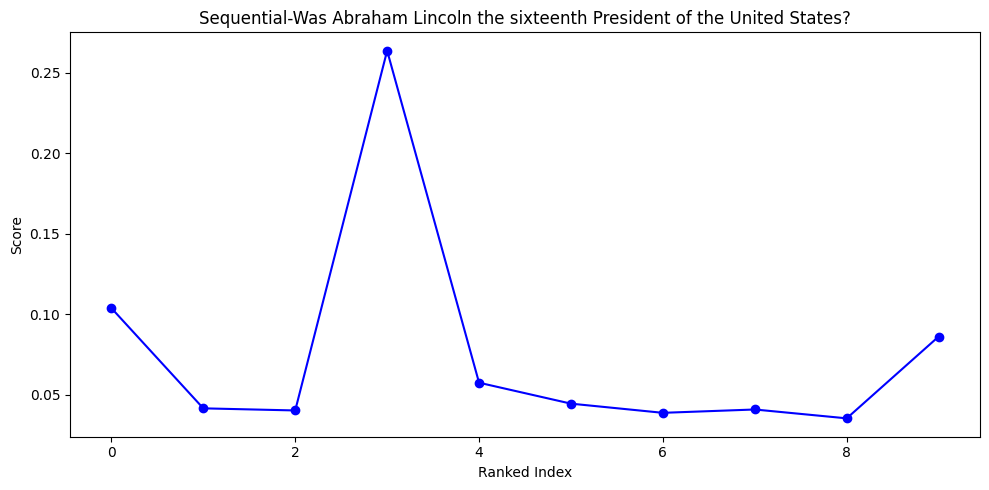

[ChatCompletionChoice(index=0, message=AssistantMessage(content='No context.', tool_calls=None, prefix=False, role='assistant'), finish_reason='stop')]


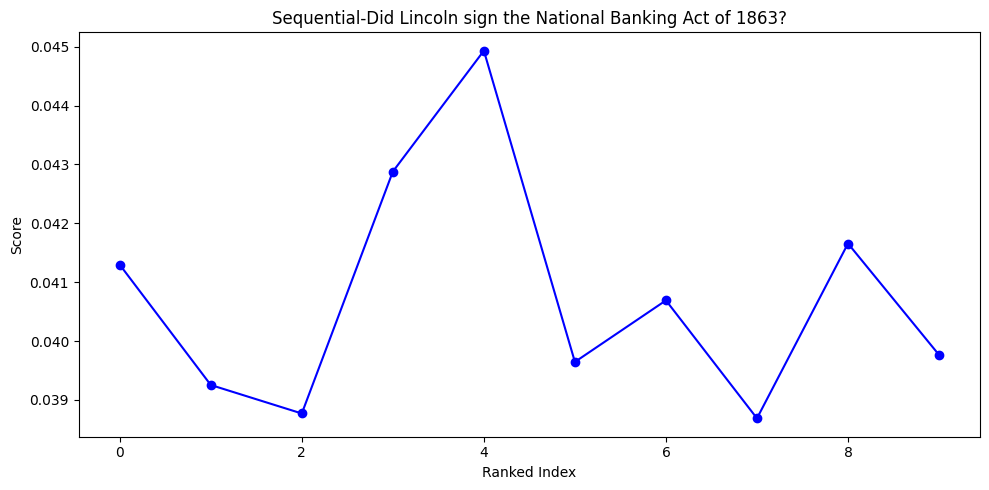

[ChatCompletionChoice(index=0, message=AssistantMessage(content='No context.', tool_calls=None, prefix=False, role='assistant'), finish_reason='stop')]


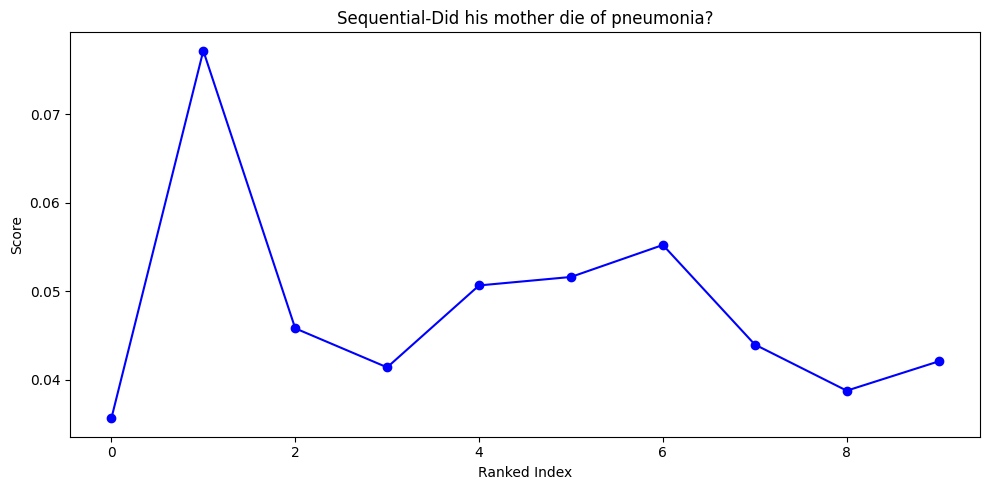

[ChatCompletionChoice(index=0, message=AssistantMessage(content='No context.', tool_calls=None, prefix=False, role='assistant'), finish_reason='stop')]


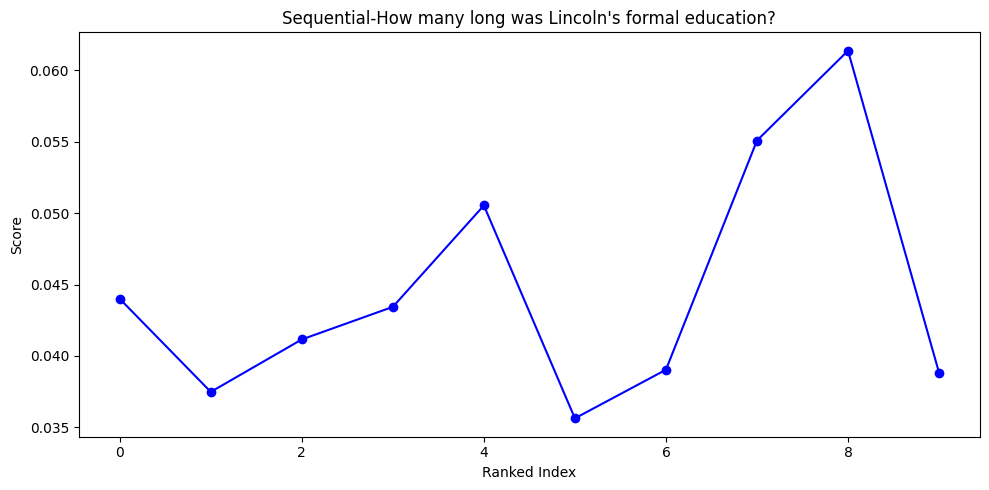

[ChatCompletionChoice(index=0, message=AssistantMessage(content='No context.', tool_calls=None, prefix=False, role='assistant'), finish_reason='stop')]


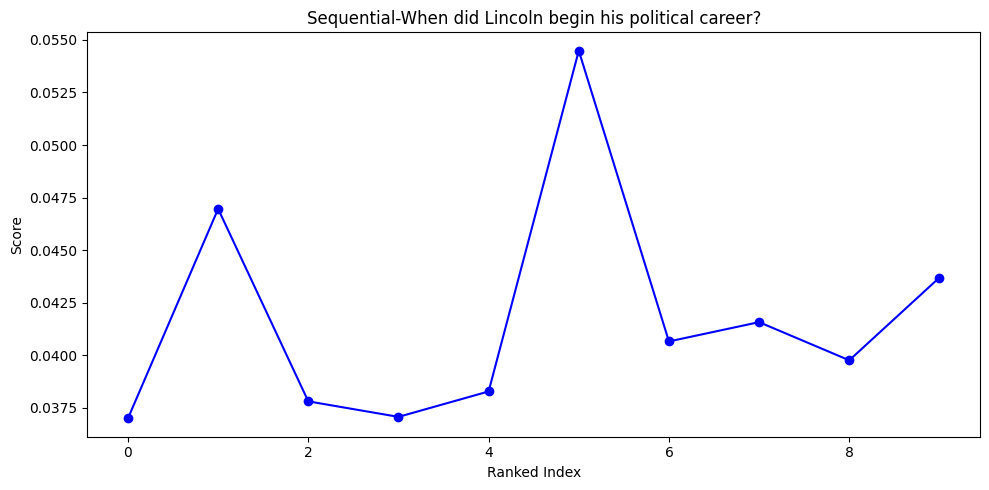

[ChatCompletionChoice(index=0, message=AssistantMessage(content='No context.', tool_calls=None, prefix=False, role='assistant'), finish_reason='stop')]


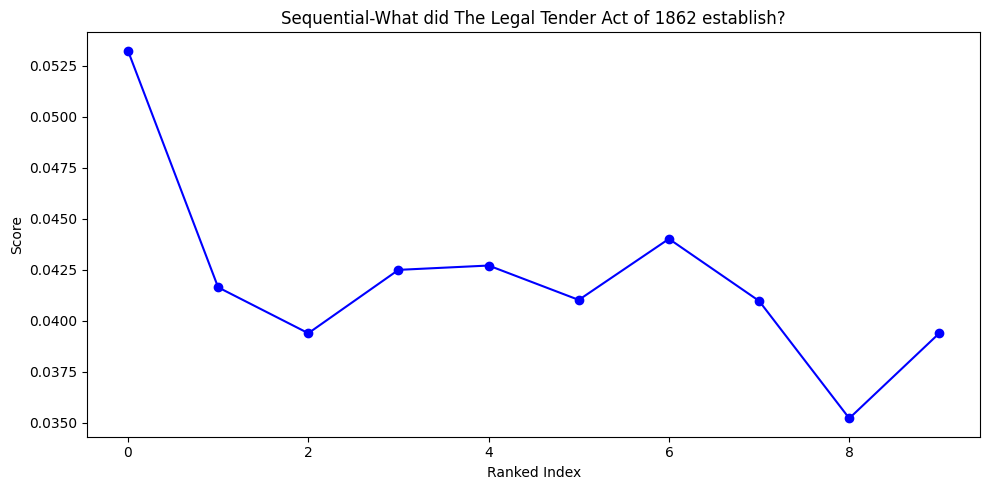

[ChatCompletionChoice(index=0, message=AssistantMessage(content='No context.', tool_calls=None, prefix=False, role='assistant'), finish_reason='stop')]


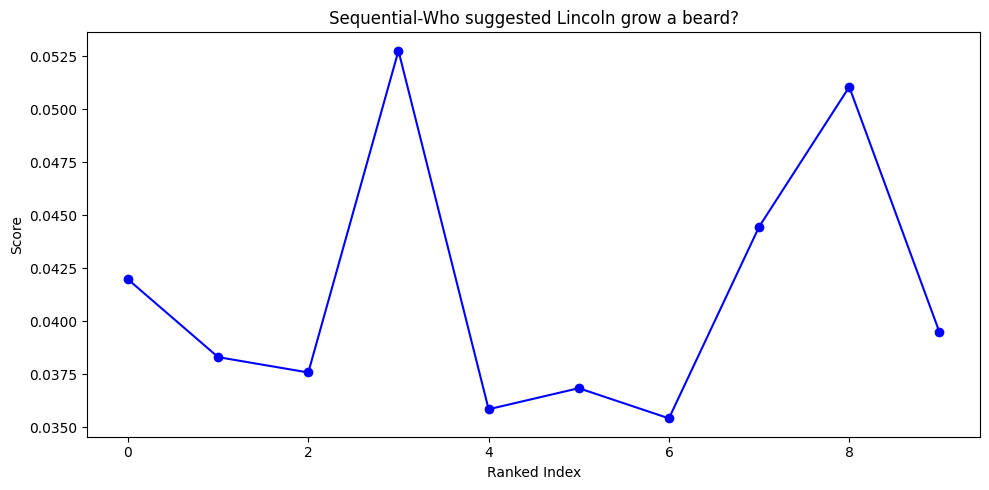

[ChatCompletionChoice(index=0, message=AssistantMessage(content='No context.', tool_calls=None, prefix=False, role='assistant'), finish_reason='stop')]


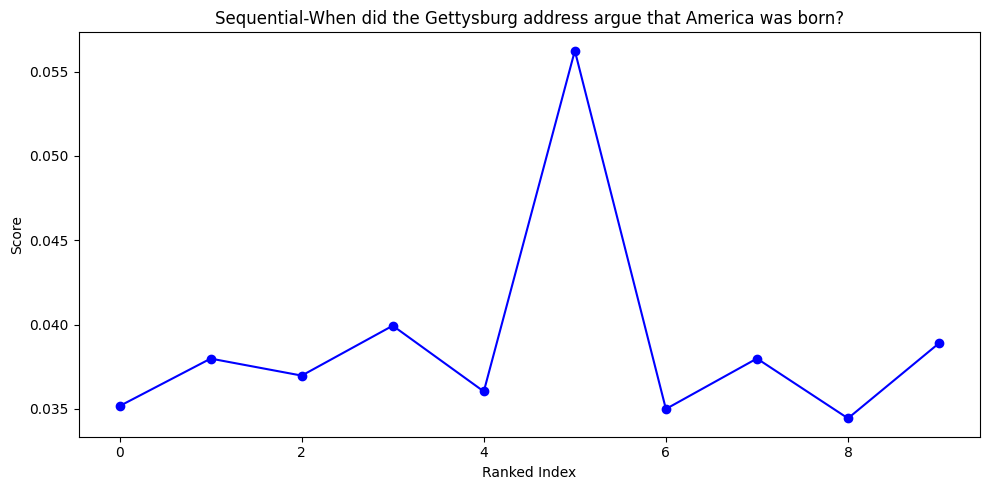

[ChatCompletionChoice(index=0, message=AssistantMessage(content='No context.', tool_calls=None, prefix=False, role='assistant'), finish_reason='stop')]


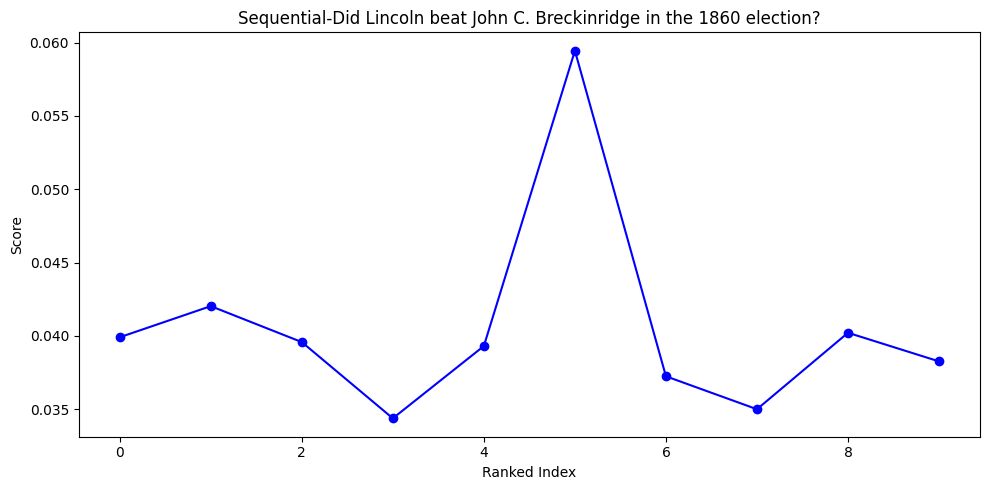

[ChatCompletionChoice(index=0, message=AssistantMessage(content='No context.', tool_calls=None, prefix=False, role='assistant'), finish_reason='stop')]


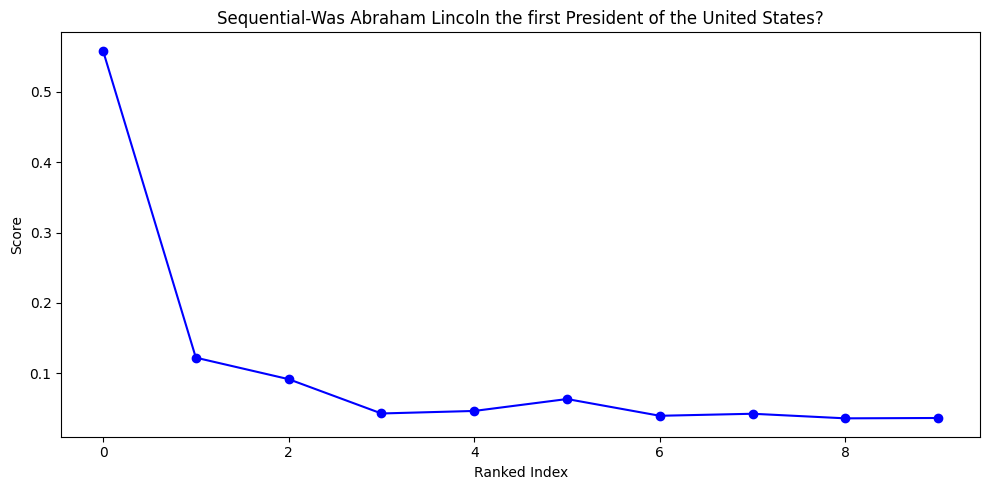

In [10]:
reranker4 = Reranker(type="sequential")
for question in questions['Question'][1:20:2]:
    documents, indices, _ = reranker4.rerank(question, context)
    answer = generator.generate_answer(question, context)
    scores = []
    for generated_answer in documents:
        score, _ = metrics.transformer_match(generated_answer, answer, question)
        scores.append(score[answer][generated_answer])
    plot_results(scores[:10], f"Sequential-{question}")


##### TF-IDF-only on the full chunked corpus.  You will need to implement a function called modules.retrieval.Reranker.tfidf_corpus_rerank().

`By applying TF-IDF across the entire chunked corpus rather than just retrieved contexts, this strategy provides a broader view of term importance and can capture global patterns in the document collection. While potentially more memory-intensive due to the larger vocabulary and document matrix, it offers more accurate term weighting by considering the full corpus statistics, making it particularly effective for domain-specific collections where term uniqueness across the entire corpus matters. The design should include a versioning system for the TF-IDF matrix to handle corpus updates without disrupting ongoing queries, possibly using a read-copy-update (RCU) pattern for concurrent access.`

[ChatCompletionChoice(index=0, message=AssistantMessage(content='No context.', tool_calls=None, prefix=False, role='assistant'), finish_reason='stop')]


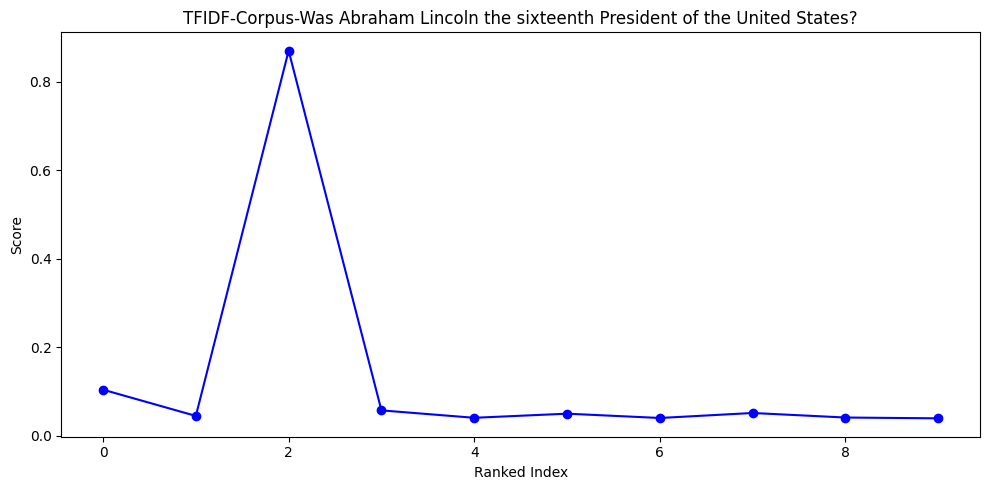

[ChatCompletionChoice(index=0, message=AssistantMessage(content='No context.', tool_calls=None, prefix=False, role='assistant'), finish_reason='stop')]


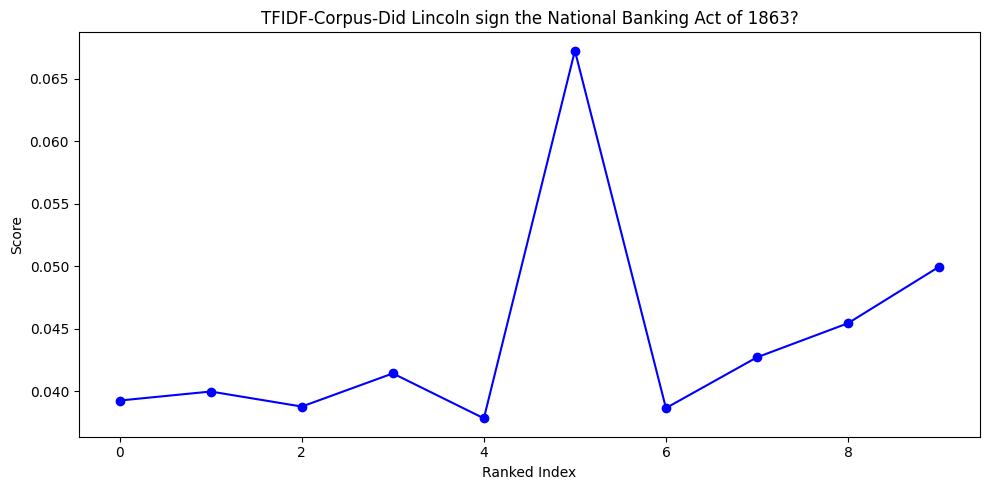

[ChatCompletionChoice(index=0, message=AssistantMessage(content='No context.', tool_calls=None, prefix=False, role='assistant'), finish_reason='stop')]


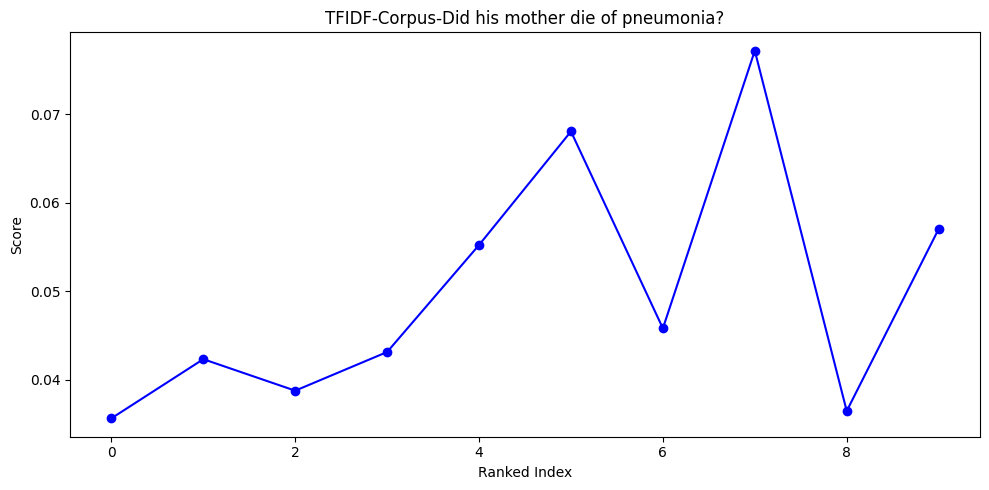

[ChatCompletionChoice(index=0, message=AssistantMessage(content='No context.', tool_calls=None, prefix=False, role='assistant'), finish_reason='stop')]


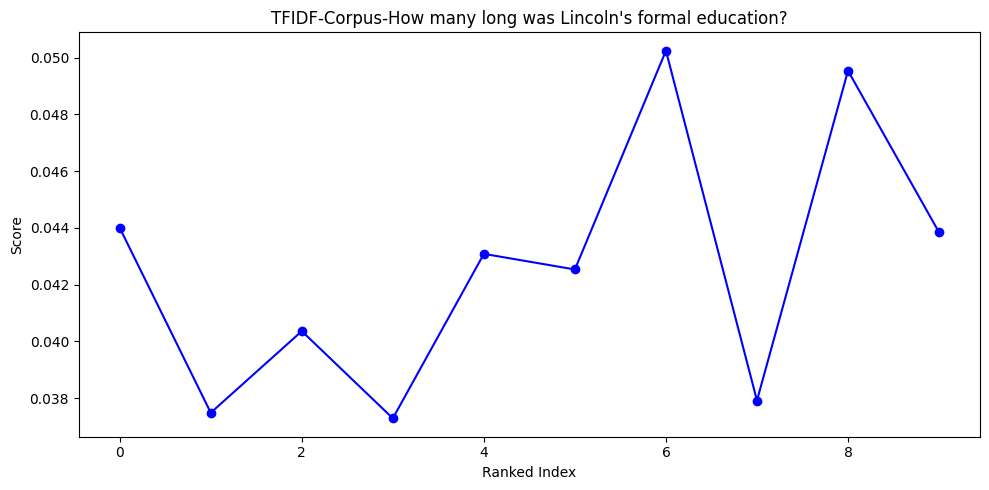

[ChatCompletionChoice(index=0, message=AssistantMessage(content='No context.', tool_calls=None, prefix=False, role='assistant'), finish_reason='stop')]


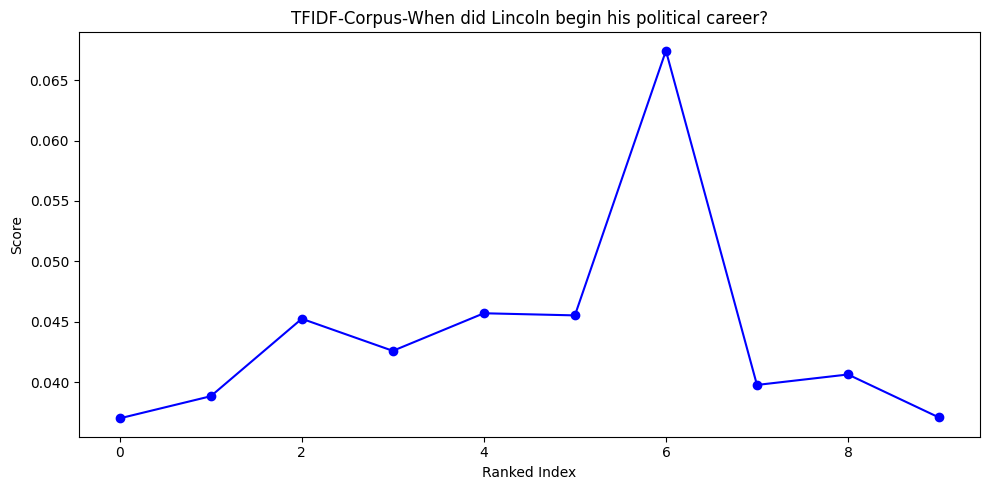

[ChatCompletionChoice(index=0, message=AssistantMessage(content='No context.', tool_calls=None, prefix=False, role='assistant'), finish_reason='stop')]


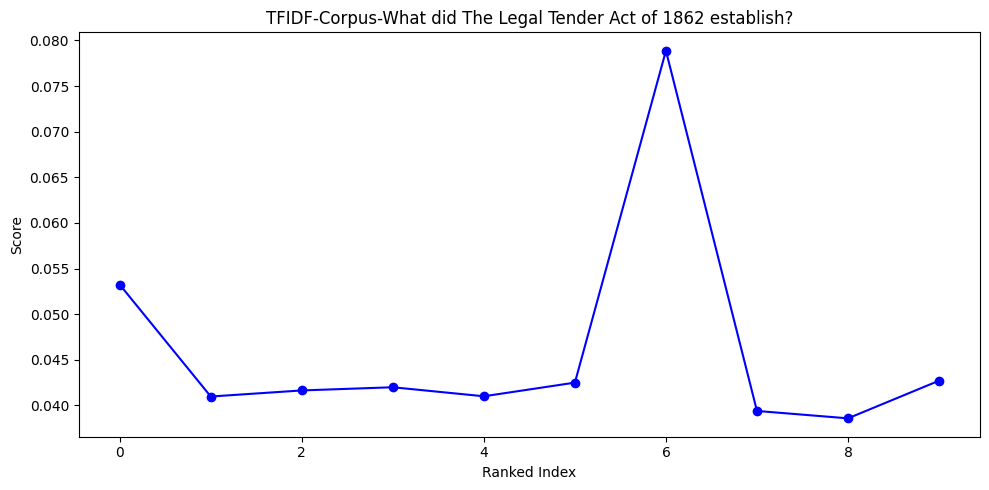

[ChatCompletionChoice(index=0, message=AssistantMessage(content='No context.', tool_calls=None, prefix=False, role='assistant'), finish_reason='stop')]


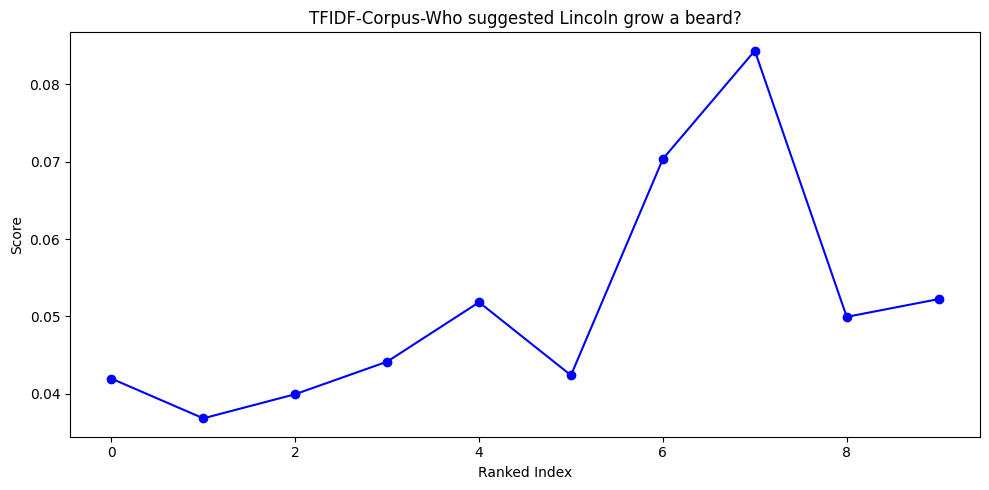

[ChatCompletionChoice(index=0, message=AssistantMessage(content='No context.', tool_calls=None, prefix=False, role='assistant'), finish_reason='stop')]


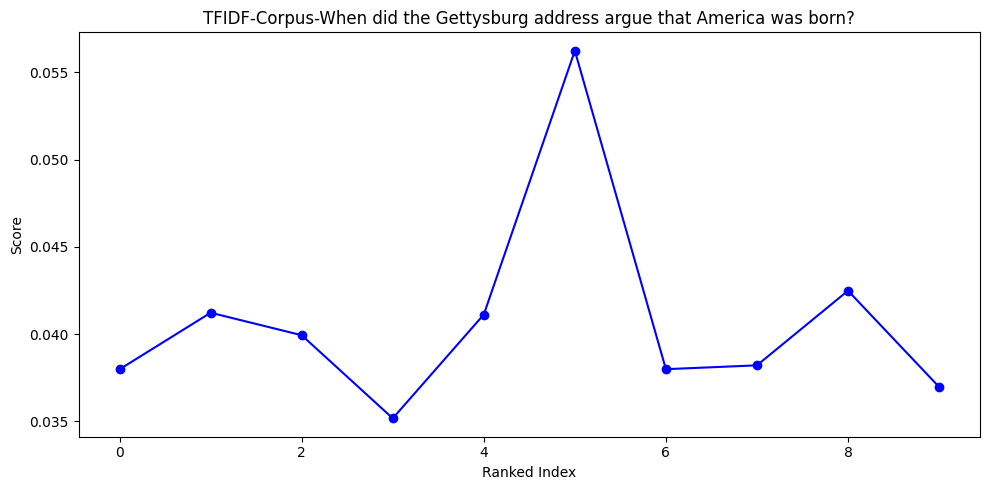

[ChatCompletionChoice(index=0, message=AssistantMessage(content='No context.', tool_calls=None, prefix=False, role='assistant'), finish_reason='stop')]


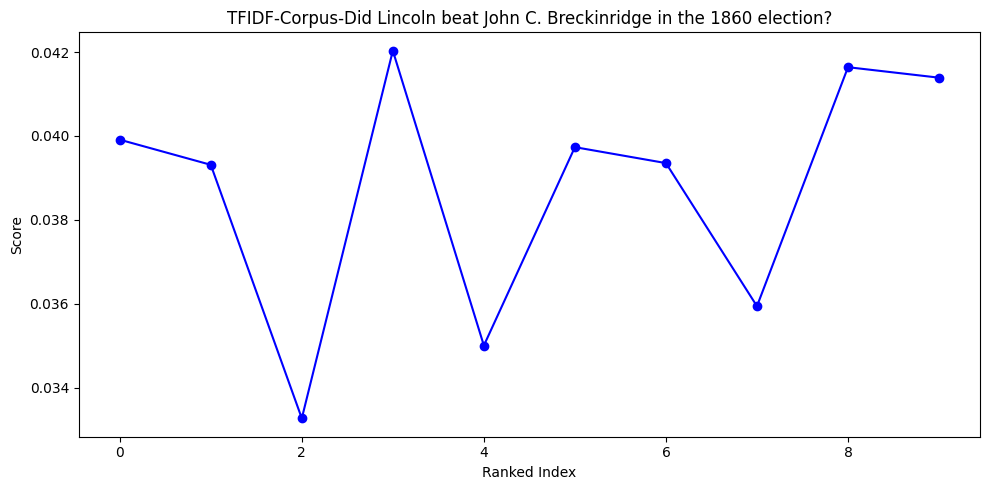

[ChatCompletionChoice(index=0, message=AssistantMessage(content='No context.', tool_calls=None, prefix=False, role='assistant'), finish_reason='stop')]


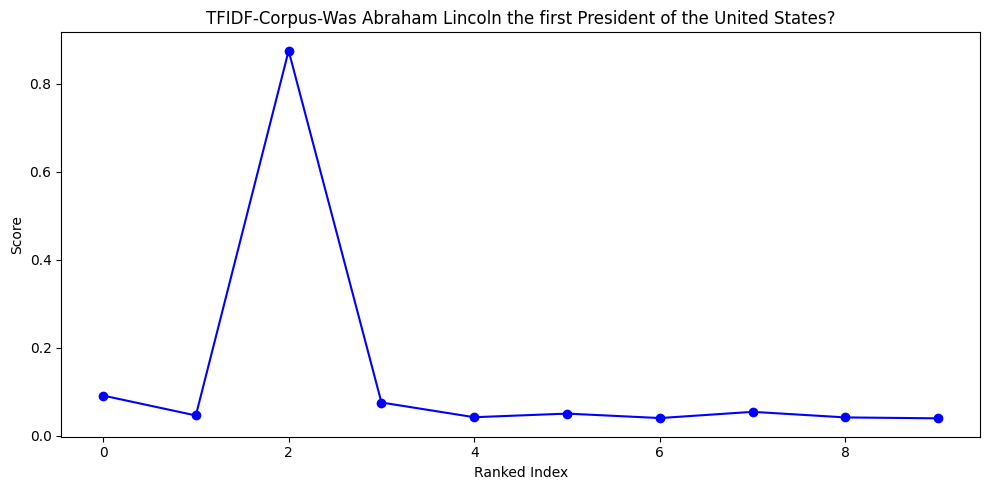

In [11]:
reranker5 = Reranker(type="tfidf_corpus")
for question in questions['Question'][1:20:2]:
    documents, indices, _ = reranker5.rerank(question, context, full_chuncked=chuncks1['chunks'])
    answer = generator.generate_answer(question, context)
    scores = []
    for generated_answer in documents:
        score, _ = metrics.transformer_match(generated_answer, answer, question)
        scores.append(score[answer][generated_answer])
    plot_results(scores[:10], f"TFIDF-Corpus-{question}")